In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2, f_classif

In [3]:
# i.) Loading the dataset
df = pd.read_csv('iris/Iris.csv')

# ii.) Exploratory Data Analysis and Visualization

# Summary Statistics
print("Summary Statistics:")
print(df.describe())

Summary Statistics:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000


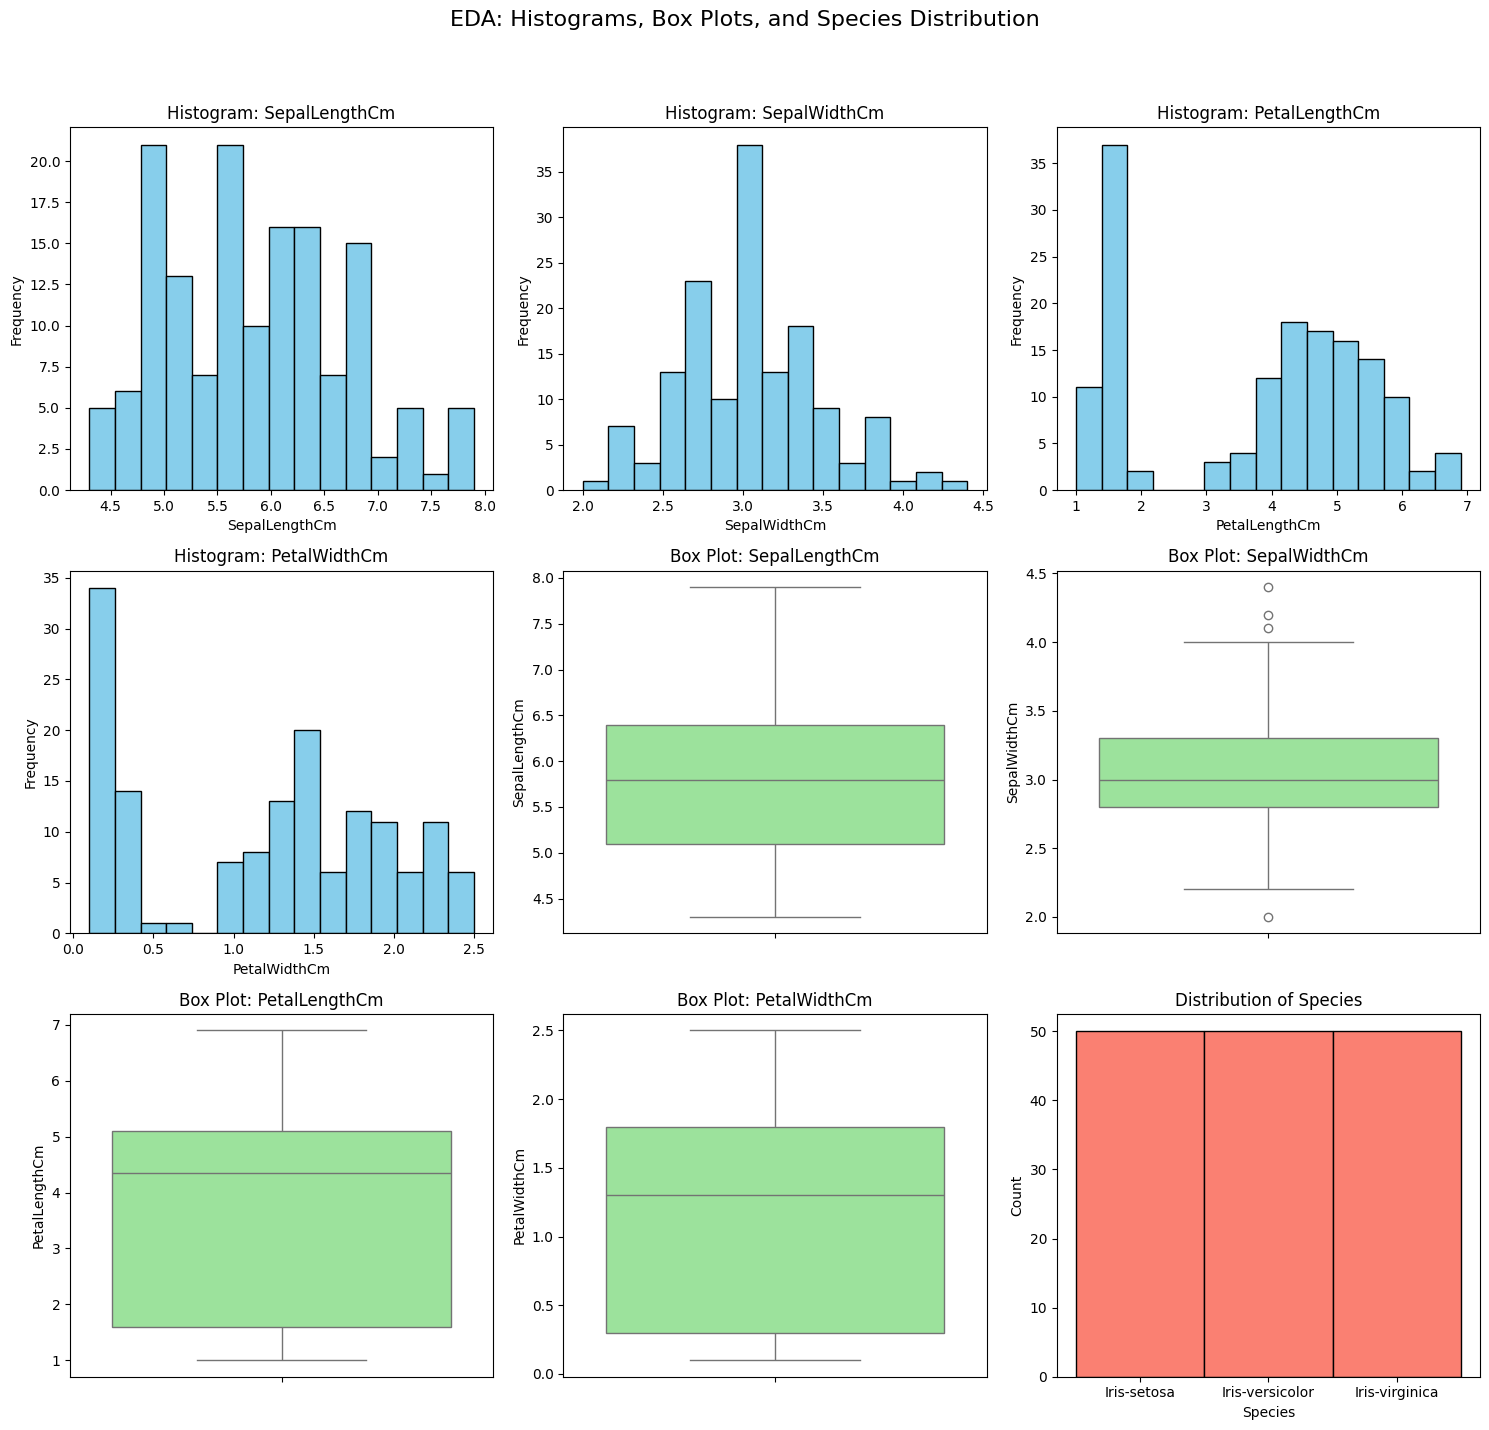

In [4]:
# --- Grid 1: Histograms, Box Plots, and Species Distribution ---
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('EDA: Histograms, Box Plots, and Species Distribution', fontsize=16)

features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
axes_flat = axes.flatten()

# 1. Histograms (Width 1)
for i, feature in enumerate(features):
    ax = axes_flat[i]
    ax.hist(df[feature], bins=15, color='skyblue', edgecolor='black', rwidth=1.0)
    ax.set_title(f'Histogram: {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')

# 2. Box Plots
for i, feature in enumerate(features):
    ax = axes_flat[i + 4]
    sns.boxplot(y=df[feature], ax=ax, color='lightgreen')
    ax.set_title(f'Box Plot: {feature}')
    ax.set_ylabel(feature)

# 3. Species Bar Chart (Width 1)
ax = axes_flat[8]
species_counts = df['Species'].value_counts()
ax.bar(species_counts.index, species_counts.values, width=1.0, color='salmon', edgecolor='black')
ax.set_title('Distribution of Species')
ax.set_xlabel('Species')
ax.set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# SAVE COMMAND FOR EPS
plt.savefig('eda_grid_1.eps', format='eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


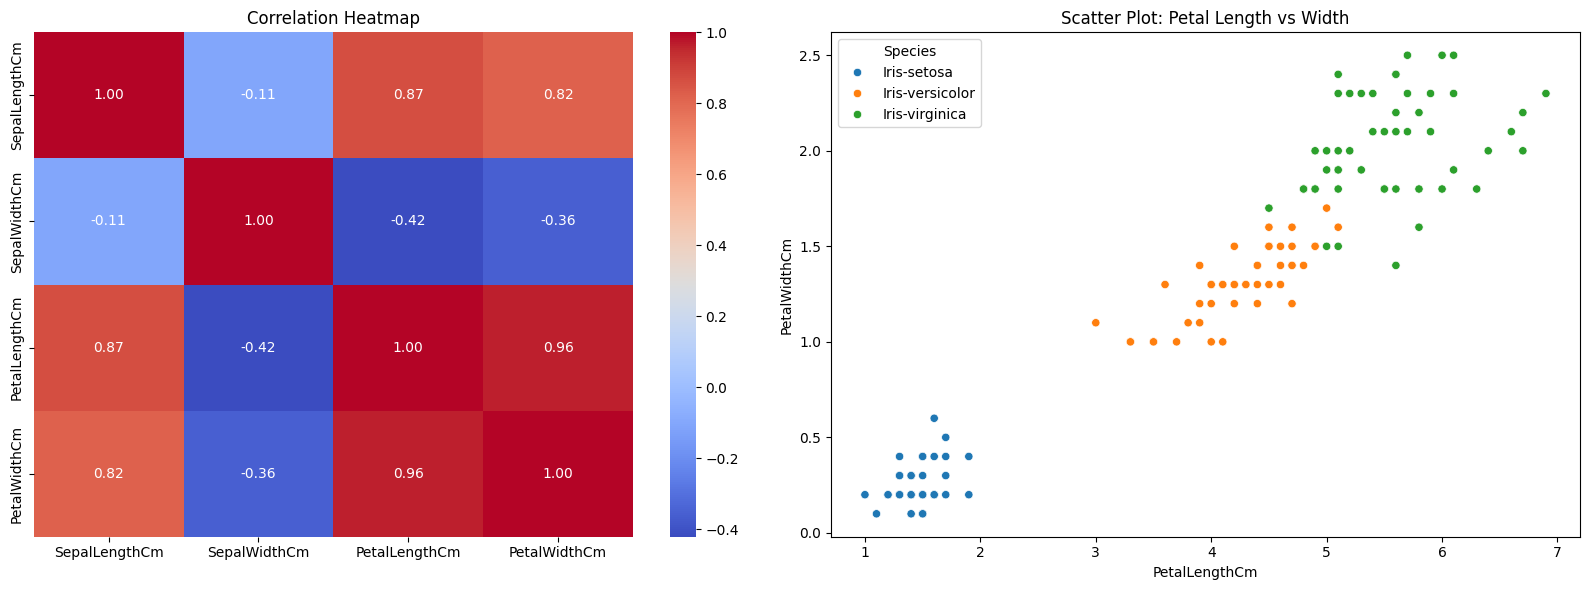

In [5]:
# --- Grid 2: Heatmap & Scatter Plot ---
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
numeric_df = df.drop(['Id', 'Species'], axis=1, errors='ignore')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes2[0])
axes2[0].set_title('Correlation Heatmap')

# Scatter Plot
sns.scatterplot(x='PetalLengthCm', y='PetalWidthCm', hue='Species', data=df, ax=axes2[1])
axes2[1].set_title('Scatter Plot: Petal Length vs Width')
axes2[1].set_xlabel('PetalLengthCm')
axes2[1].set_ylabel('PetalWidthCm')

plt.tight_layout()

# SAVE COMMAND FOR EPS
plt.savefig('eda_grid_2.eps', format='eps')
plt.show()

In [6]:
# iii.) Data Preprocessing
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

le = LabelEncoder()
df['Species_Encoded'] = le.fit_transform(df['Species'])

X = df.drop(['Species', 'Species_Encoded'], axis=1)
y = df['Species_Encoded']

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# iv.) Feature Selection
# Chi-Square (needs positive values, use original X)
chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X, y)
chi2_res = pd.DataFrame({'Feature': X.columns, 'Score': chi2_selector.scores_})
print("Chi-Square Scores:\n", chi2_res.sort_values(by='Score', ascending=False))

# ANOVA (use standardized X)
anova_selector = SelectKBest(f_classif, k='all')
anova_selector.fit(X_scaled, y)
anova_res = pd.DataFrame({'Feature': X.columns, 'Score': anova_selector.scores_})
print("\nANOVA Scores:\n", anova_res.sort_values(by='Score', ascending=False))

Chi-Square Scores:
          Feature       Score
2  PetalLengthCm  116.169847
3   PetalWidthCm   67.244828
0  SepalLengthCm   10.817821
1   SepalWidthCm    3.594499

ANOVA Scores:
          Feature        Score
2  PetalLengthCm  1179.034328
3   PetalWidthCm   959.324406
0  SepalLengthCm   119.264502
1   SepalWidthCm    47.364461


In [8]:
# v.) Data Splitting
# 70% Train, 15% Val, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\nData Splitting:\nTrain shape: {X_train.shape}\nVal shape: {X_val.shape}\nTest shape: {X_test.shape}")


Data Splitting:
Train shape: (105, 4)
Val shape: (22, 4)
Test shape: (23, 4)
